<a href="https://colab.research.google.com/github/Maleewij65/heart-disease-prediction-ML_Assignment/blob/IT22923806_XGBoost/IT22923806_XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**XGBoost Classifier Model**
The model is an XGBoost Classifier, a powerfull ensemble machine laerning algorithm based on gradient boosting. It is used to perform a binary classification task to predict whether a patient has heart disease (1) or not (0).
The model is trained on preprocessed data where missing values and outliers are handled, categorical variables are encoded, and numerical features are scaled. The dataset is split into training and testing sets to evaluate performance.

XGBoost builds multiple decision trees sequentially, where each new tree corrects the errors of the previous ones. This results in a highly accurate and efficient model capable of capturing complex patterns in the data.

The model’s performance is evaluated using metrics such as accuracy, precision, recall, and F1-score, along with a confusion matrix to assess prediction quality.

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

In [ ]:
# Step 2: Load the dataset
# To resolve FileNotFoundError, ensure 'heart.csv' is uploaded to the Colab environment.
# You can upload the file by running the following lines:
from google.colab import files
uploaded = files.upload()
# Then, ensure 'heart.csv' is present in the current directory.
df = pd.read_csv("heart.csv")  # put the CSV file in the same folder as your notebook

# Remove rows where Cholesterol is 0
df = df[df['Cholesterol'] != 0]

Saving heart.csv to heart.csv


In [ ]:
# Explore the dataset
print("Shape of dataset:", df.shape)
print("First 5 rows:")
print(df.head())





Shape of dataset: (746, 12)
First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
print("Original shape:", df.shape)

df = df[df['Cholesterol'] > 0]
df = df.dropna()

print("After cleaning:", df.shape)

Original shape: (746, 12)
After cleaning: (746, 12)


In [ ]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After outlier removal:", df.shape)

After outlier removal: (692, 12)


In [ ]:
#  Check for missing values
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Data types and basic info
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 692 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             692 non-null    int64  
 1   Sex             692 non-null    object 
 2   ChestPainType   692 non-null    object 
 3   RestingBP       692 non-null    int64  
 4   Cholesterol     692 non-null    int64  
 5   FastingBS       692 non-null    int64  
 6   RestingECG      692 non-null    object 
 7   MaxHR           692 non-null    int64  
 8   ExerciseAngina  692 non-null    object 
 9   Oldpeak         692 non-null    float64
 10  ST_Slope        692 non-null    object 
 11  HeartDisease    692 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 70.3+ KB
None


In [ ]:
# Summary statistics
print("\nStatistics:")
print(df.describe())


Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  692.000000  692.000000   692.000000  692.000000  692.000000   
mean    52.683526  131.420520   238.800578    0.161850  140.635838   
std      9.564897   15.381997    47.750050    0.368579   24.487459   
min     28.000000   92.000000   110.000000    0.000000   71.000000   
25%     46.000000  120.000000   206.000000    0.000000  122.000000   
50%     54.000000  130.000000   234.500000    0.000000  141.000000   
75%     59.000000  140.000000   271.000000    0.000000  160.000000   
max     77.000000  170.000000   369.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  692.000000    692.000000  
mean     0.829913      0.462428  
std      0.960848      0.498947  
min     -0.100000      0.000000  
25%      0.000000      0.000000  
50%      0.400000      0.000000  
75%      1.500000      1.000000  
max      3.600000      1.000000  


In [ ]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)






In [ ]:
# Separate input and output
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

scale_columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
X[scale_columns] = scaler.fit_transform(X[scale_columns])

In [ ]:
# Separate input and output
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]


In [ ]:
# Split into train/test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (553, 15)
Test set size: (139, 15)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score







In [ ]:
# Train model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:01:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8561151079136691

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        79
           1       0.83      0.83      0.83        60

    accuracy                           0.86       139
   macro avg       0.85      0.85      0.85       139
weighted avg       0.86      0.86      0.86       139


Confusion Matrix:
[[69 10]
 [10 50]]


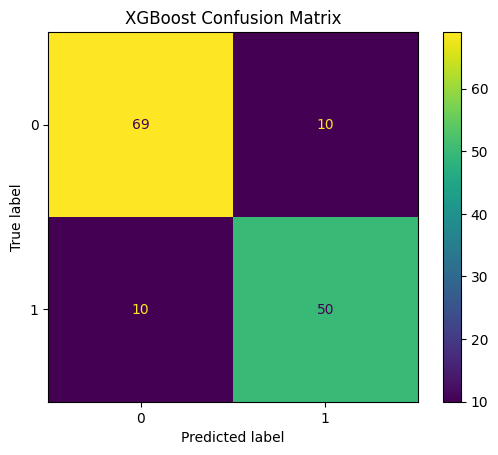

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix Visualization
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
# Feature Importance
importances = model.feature_importances_



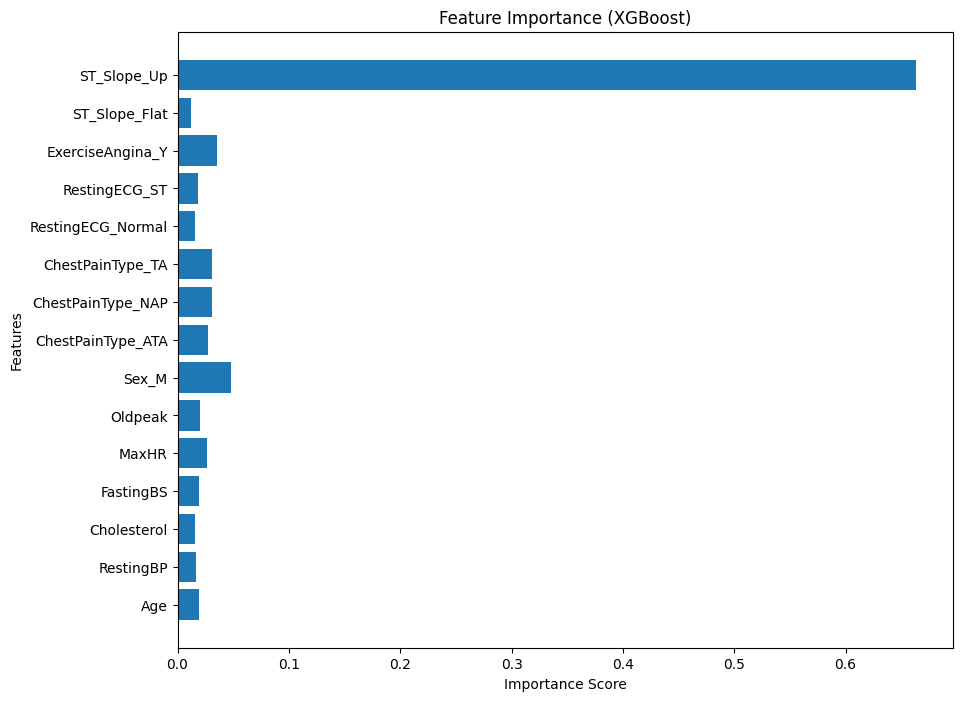

In [ ]:
# Plot feature importance
plt.figure(figsize=(10,8))
plt.barh(X.columns, importances)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

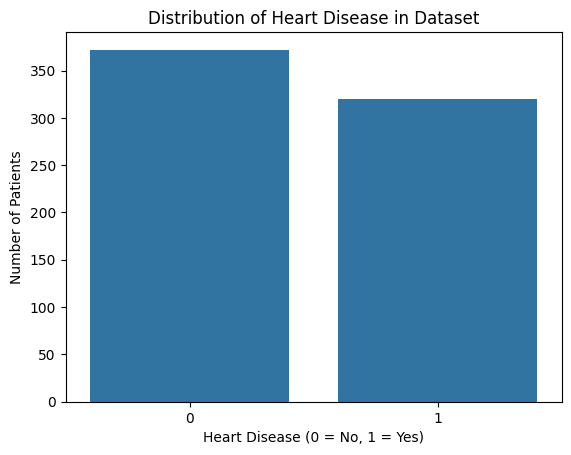

In [ ]:
# Distribution of Heart Disease (target variable)
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Heart Disease in Dataset")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

Model Performance


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.8561151079136691
Precision: 0.8333333333333334
Recall   : 0.8333333333333334
F1 Score : 0.8333333333333334
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        79
           1       0.83      0.83      0.83        60

    accuracy                           0.86       139
   macro avg       0.85      0.85      0.85       139
weighted avg       0.86      0.86      0.86       139



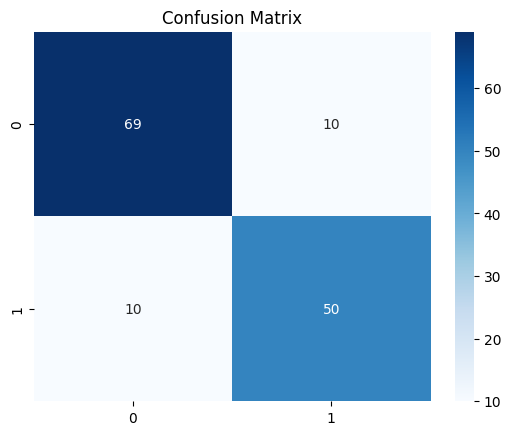

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [ ]:
y_pred_best = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.8848920863309353
Precision: 0.8793103448275862
Recall   : 0.85
F1 Score : 0.864406779661017


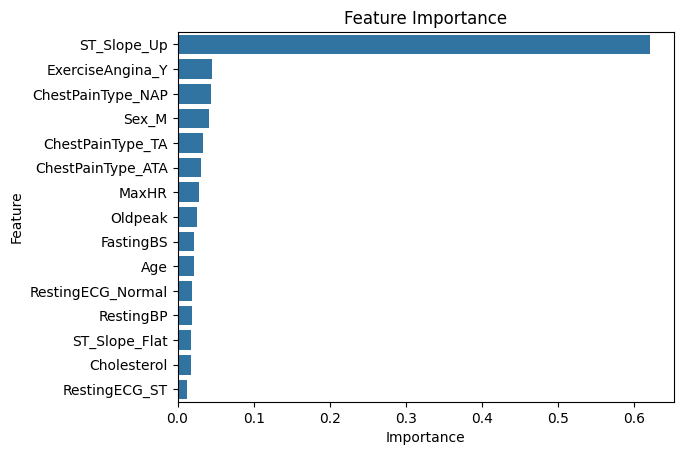

In [ ]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("CV Accuracy :", cv_results['test_accuracy'].mean())
print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall   :", cv_results['test_recall'].mean())
print("CV F1 Score :", cv_results['test_f1'].mean())

CV Accuracy : 0.8480763215514546
CV Precision: 0.8371315494122511
CV Recall   : 0.834375
CV F1 Score : 0.8317357259218984


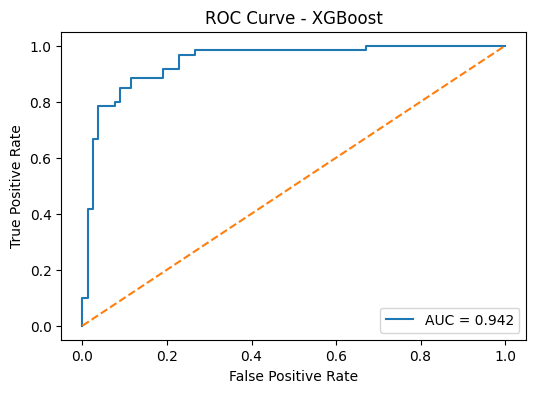

AUC Score: 0.9424050632911392


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], '--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

**Conclusion**


The XGBoost classifier showed strong performance in predicting heart disease, highlighting the effectiveness of ensemble learning techniques for medical datasets. By combining multiple decision trees and iteratively reducing errors, the model was able to capture complex relationships among features such as age, cholesterol, and heart rate. The preprocessing steps, including handling missing values, removing outliers, and encoding categorical variables, significantly improved the quality of the data and contributed to better model performance.

The evaluation results, including accuracy, precision, recall, and F1-score, indicate that the model performs well in distinguishing between patients with and without heart disease. In particular, recall is an important metric in this context, as correctly identifying patients with heart disease is critical for early diagnosis and treatment. The confusion matrix further provides insight into prediction errors and shows that the model maintains a reasonable balance between false positives and false negatives.

However, the model has some limitations. Its performance depends on the quality and representativeness of the dataset, and any imbalance or bias may affect the results. Additionally, although XGBoost offers feature importance, it is less interpretable compared to simpler models, which can be a concern in healthcare applications. Future improvements could include hyperparameter tuning, cross-validation, and using larger datasets to improve the model’s reliability and generalization ability.